In [1]:
import pandas as pd
import numpy as np
import networkx as nx

from scipy.spatial import distance
from tqdm.notebook import tqdm
import seaborn as sns

import umap

In [2]:
df = pd.read_csv('csv/flat-training.csv')

In [3]:
object_columns = []
for column in df.columns:
    if df[[column]].dtypes[0] == 'object':
        object_columns.append(column)

/tmp/ipykernel_9281/2539580127.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df[[column]].dtypes[0] == 'object':
/tmp/ipykernel_9281/2539580127.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df[[column]].dtypes[0] == 'object':
/tmp/ipykernel_9281/2539580127.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df[[column]].dtypes[0] == 'object':
/tmp/ipykernel_9281/2539580127.py:3: FutureWarning: Series.__getitem__

In [4]:
nonobject_columns = [x for x in df.columns.tolist() if x not in object_columns]

df_no = df[nonobject_columns]

df_no.corr() > 0.2

,dog,rabbit,deer,panda,hedgehog,squirrel,dolphin,penguin,turtle,elephant,...,apple,honey,pumpkin,button,whistle,marble,wagon,storybook,clover,bubble
dog,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
rabbit,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
deer,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
panda,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
hedgehog,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
squirrel,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
dolphin,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
penguin,False,False,False,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
turtle,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
elephant,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isna().sum()

dog              0
cat              0
rabbit       75976
deer             0
panda            0
             ...  
storybook        0
candle           0
clover           0
bubble           0
cookie           0
Length: 80, dtype: int64

In [5]:
distance.cosine(df_no.loc[0].fillna(0).tolist(), df_no.loc[1].fillna(0).tolist())

np.float64(0.18103237746316236)

In [7]:
from itertools import combinations

subsets = list(combinations(df_no, 2))

In [8]:
def row_evaluate(df, i, fill_na_value):
    return df.loc[i].fillna(fill_na_value).tolist()

row_number = []
also_row_number = []
rows = []
also_rows = []
cosine_distances = []
for i, row in tqdm(enumerate(range(0,df_no.shape[0])),total=df_no.shape[0]):
    for j, also_row in enumerate(range(0,df_no.shape[0])):
        if i != j:
            row_1 = row_evaluate(df_no, i, 0)
            row_2 = row_evaluate(df_no, j, 0)
            row_number.append(i)
            also_row_number.append(j)
            rows.append(row_1)
            also_rows.append(row_2)
            cosine_distances.append(distance.cosine(row_1, row_2))

  0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

sample_df = df_no.sample(1000)

# Calculate cosine similarity for consecutive rows
row_number = []
also_row_number = []
rows = []
also_rows = []
distance_list = []
for i in tqdm(range(len(sample_df) - 1), total=sample_df.shape[0]-1):
    for j in range(len(sample_df) - 1):
        if j>i:
            row_number.append(i)
            also_row_number.append(j)
            row1 = sample_df.iloc[i].fillna(0).values.reshape(1, -1)
            row2 = sample_df.iloc[j].fillna(0).values.reshape(1, -1)
            similarity = cosine_similarity(row1, row2)[0][0]
            distance_list.append(1-similarity)

  0%|          | 0/999 [00:00<?, ?it/s]

In [10]:
len(row_number), len(also_row_number),len(distance_list)

(498501, 498501, 498501)

In [11]:
col_dict = {
    "row_number": row_number,
    "second_row_number": also_row_number,
    "distance": distance_list
}

sample_df_distances = pd.DataFrame.from_dict(col_dict)

<Axes: xlabel='distance', ylabel='Count'>

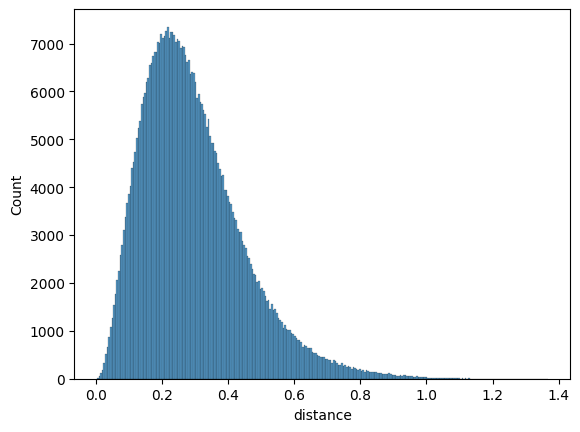

In [12]:
sns.histplot(sample_df_distances['distance'])

In [13]:
R = 0.1
df_R = sample_df_distances[sample_df_distances.distance < R]

G=nx.from_pandas_edgelist(df_R, 'row_number', 'second_row_number', edge_attr='distance')

In [14]:
nx.is_connected(G)

False

In [15]:
G.degree

DegreeView({0: 39, 66: 131, 94: 164, 99: 146, 139: 169, 145: 141, 174: 164, 183: 5, 199: 130, 212: 78, 249: 110, 258: 128, 322: 133, 413: 51, 423: 126, 444: 154, 447: 130, 483: 13, 488: 34, 505: 45, 507: 90, 511: 131, 588: 20, 627: 86, 680: 131, 682: 134, 718: 58, 751: 126, 753: 143, 762: 137, 774: 27, 796: 40, 804: 89, 811: 64, 847: 137, 862: 146, 945: 161, 948: 10, 955: 96, 960: 126, 1: 75, 13: 75, 14: 136, 18: 216, 20: 81, 23: 64, 25: 77, 36: 136, 61: 37, 67: 48, 92: 166, 93: 194, 104: 206, 111: 85, 112: 61, 121: 121, 127: 89, 134: 73, 169: 110, 172: 160, 178: 114, 186: 157, 195: 25, 227: 207, 229: 208, 245: 19, 259: 28, 265: 97, 282: 208, 297: 96, 303: 18, 307: 20, 310: 175, 355: 151, 356: 42, 368: 87, 384: 123, 391: 168, 400: 38, 418: 159, 454: 17, 462: 105, 473: 160, 504: 175, 516: 64, 527: 160, 535: 209, 547: 51, 552: 116, 559: 186, 581: 70, 622: 149, 666: 11, 672: 94, 688: 140, 692: 67, 693: 46, 695: 142, 705: 142, 719: 130, 734: 172, 735: 91, 741: 26, 756: 92, 761: 122, 790: 1

In [16]:
G_biggest_simplex = G.subgraph(sorted(nx.find_cliques(G), key=len, reverse=True)[0])

In [17]:
G_biggest_simplex.degree

DegreeView({257: 52, 258: 52, 139: 52, 907: 52, 399: 52, 145: 52, 533: 52, 409: 52, 538: 52, 26: 52, 30: 52, 673: 52, 802: 52, 423: 52, 680: 52, 682: 52, 174: 52, 945: 52, 438: 52, 822: 52, 698: 52, 955: 52, 443: 52, 447: 52, 960: 52, 322: 52, 66: 52, 711: 52, 199: 52, 73: 52, 330: 52, 202: 52, 847: 52, 721: 52, 465: 52, 342: 52, 216: 52, 345: 52, 90: 52, 89: 52, 472: 52, 221: 52, 94: 52, 730: 52, 99: 52, 358: 52, 360: 52, 113: 52, 499: 52, 244: 52, 249: 52, 762: 52, 511: 52})

In [18]:
diam = nx.diameter(G)

NetworkXError: Found infinite path length because the graph is not connected

In [175]:
from sklearn.model_selection import train_test_split

df_no_fillna = df_no.fillna(0)

X_train, X_test = train_test_split(df_no_fillna, train_size=0.8)

from sklearn.preprocessing import StandardScaler
reducer = umap.UMAP(metric='cosine', n_neighbors = 50, n_components=2)
scaler = StandardScaler()

In [176]:
scaler.fit(df_no_fillna)

X_train_scaled = scaler.transform(df_no_fillna)

In [177]:
embedding = reducer.fit_transform(X_train_scaled)

/home/fnnsll/.cache/pypoetry/virtualenvs/synthetic-ar5qwqp6-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [164]:
embedding.shape

(100000, 2)

In [178]:
plot_df = pd.DataFrame(embedding)

plot_df.columns = [f'col{i}' for i in range(plot_df.shape[1])]

final_plot_df = pd.DataFrame()

for i in range(plot_df.shape[1]):
    for j in range(plot_df.shape[1]):
        if i >= j:
            col1 = f'col{i}'
            col2 = f'col{j}'
            tmp_df = plot_df[[col1, col2]]
            tmp_df.columns = ['x','y']
            tmp_df['value_1'] = [i]*tmp_df.shape[0]
            tmp_df['value_2'] = [j]*tmp_df.shape[0]
            final_plot_df = pd.concat([final_plot_df, tmp_df], axis = 0)

/tmp/ipykernel_9281/2327447178.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['value_1'] = [i]*tmp_df.shape[0]
/tmp/ipykernel_9281/2327447178.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['value_2'] = [j]*tmp_df.shape[0]
/tmp/ipykernel_9281/2327447178.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [173]:
plot_df

,col0,col1
0,6.766385,0.000161
1,6.401069,0.178371
2,8.192944,-0.318928
3,11.750525,-7.381464
4,14.150637,6.892011
...,...,...
99995,7.251693,-5.665077
99996,11.997344,-3.099361
99997,6.632606,1.372131
99998,8.229989,-5.800306


<Axes: xlabel='col0', ylabel='col1'>

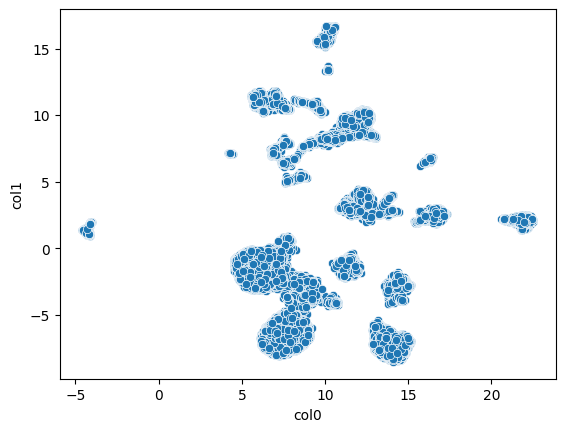

In [179]:
sns.scatterplot(plot_df, x='col0', y='col1')

In [180]:
numeric_plot_df = plot_df.copy()

In [24]:
final_plot_df = final_plot_df.set_index(['value_1','value_2'])

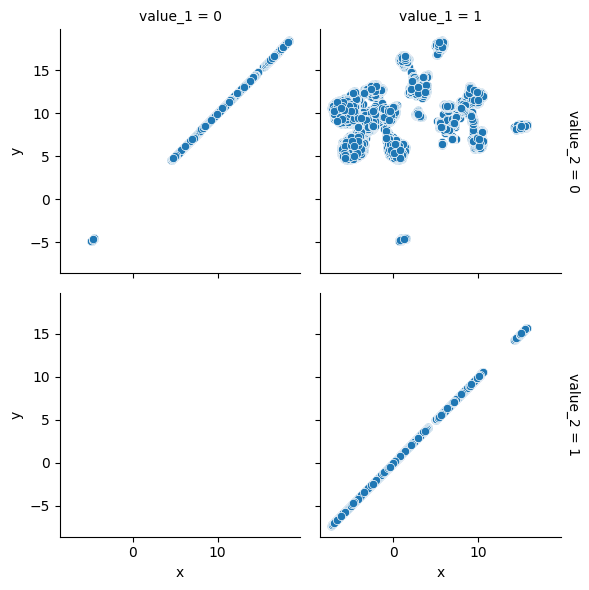

In [142]:
import matplotlib.pyplot as plt

g = sns.FacetGrid(final_plot_df.reset_index(), col='value_1', row='value_2', margin_titles=True)
g.map_dataframe(sns.scatterplot, x='x', y='y')
plt.show()

In [41]:
df_o = df[object_columns]

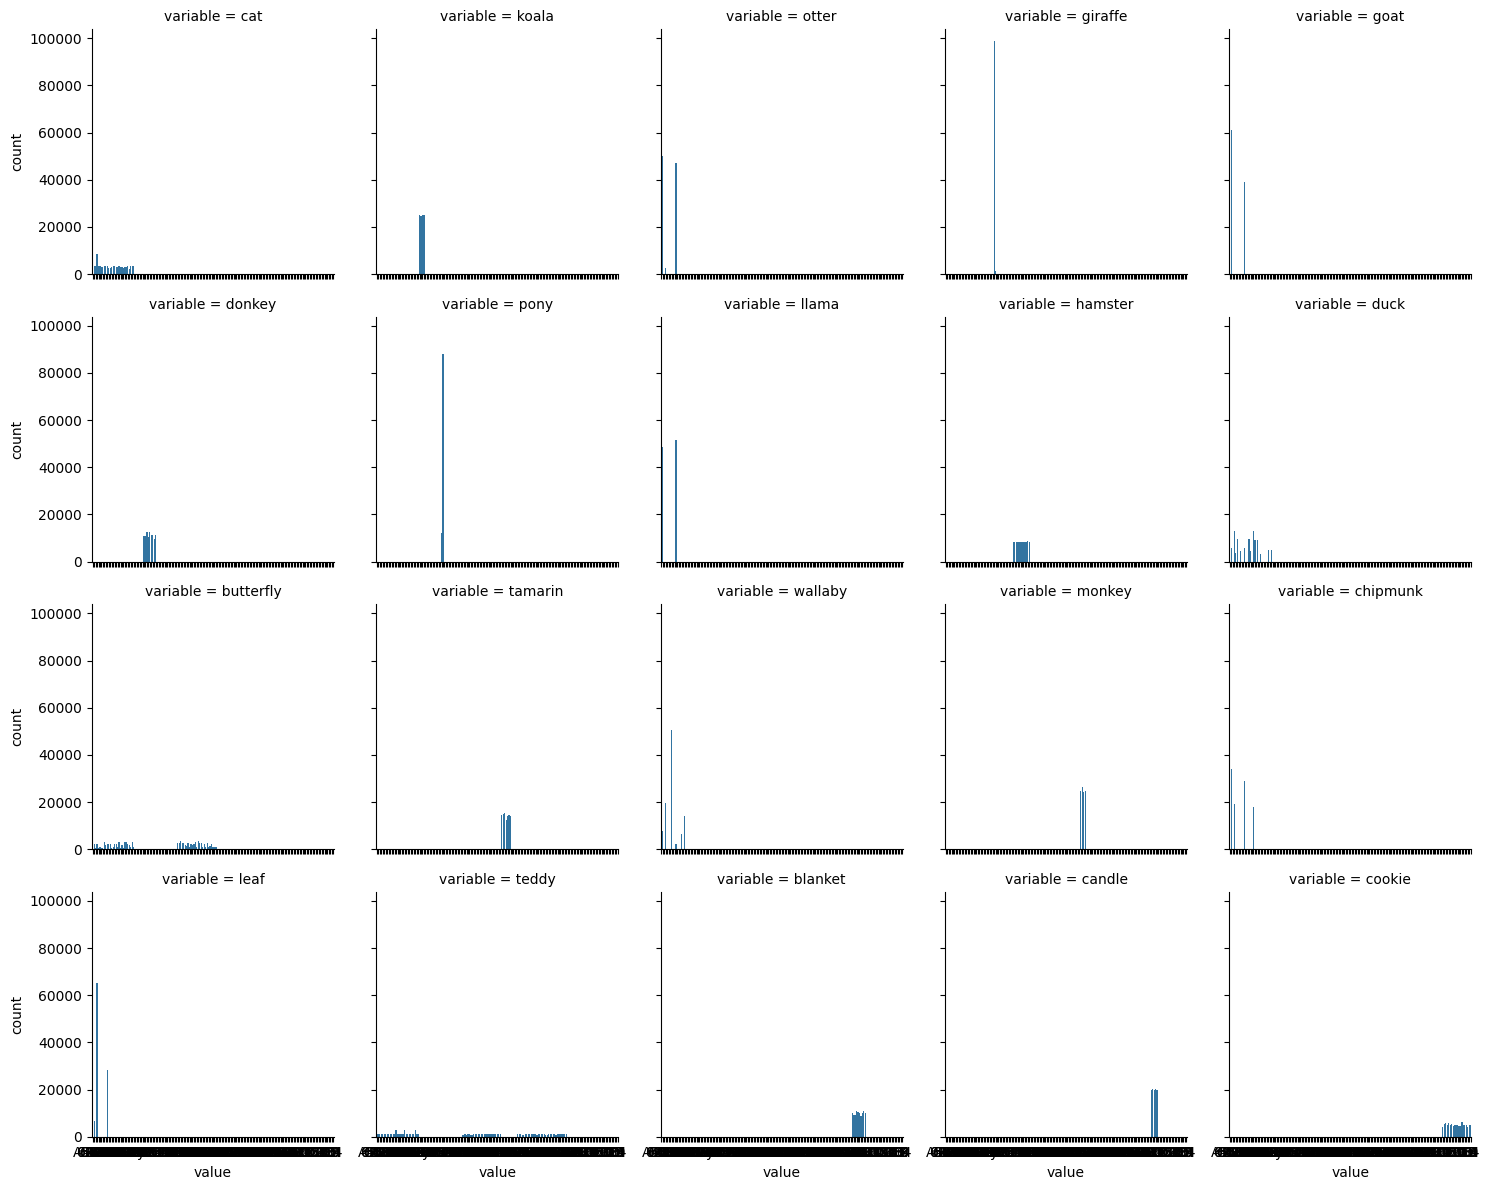

In [39]:
g = sns.FacetGrid(df_o[object_columns].melt(), col='variable', col_wrap=5)
g.map_dataframe(sns.countplot, x='value')
plt.show()

In [54]:
sum(df_o.loc[1] == df_o.loc[2])


6

In [ ]:
set(df_o.loc[1].values.tolist())

['A5DB',
 'T3',
 '027A',
 'y',
 'B9DE',
 'X7',
 'M',
 'B9DE',
 'D4',
 '248B',
 '9AB6',
 'Y0',
 'C09E',
 'Z0',
 '5A6C',
 'C09E',
 '248B',
 'A7',
 'B0',
 'C15']

In [117]:
def jaccard_distance(vect_1, vect_2):
    union = set(vect_1.values.tolist()).union(set(vect_2.values.tolist()))
    similarity = sum(vect_1 == vect_2)/len(union)
    return 1-similarity



weight = df_o.melt()['value'].nunique()

jaccard_distance(df_o.loc[1], df_o.loc[2])

sample_df = df_o.sample(1000).fillna('iamna')

sample_df.index

index_1 = []
index_2 = []
row_1 = []
row_2 = []
jaccard_dist = []
for i, row in tqdm(enumerate(sample_df.index), total=sample_df.shape[0]):
    for j, also_row in enumerate(sample_df.index):
        index_1.append(i)
        index_2.append(j)
        row_1.append(row)
        row_2.append(also_row)
        jaccard_dist.append(jaccard_distance(sample_df.loc[row], sample_df.loc[also_row]))

col_dict = {
    'index_1': index_1,
    'index_2': index_2,
    'row_1': row_1,
    'row_2': row_2,
    'distance': jaccard_dist
}

result_df = pd.DataFrame.from_dict(col_dict)

  0%|          | 0/1000 [00:00<?, ?it/s]

<Axes: xlabel='distance', ylabel='Count'>

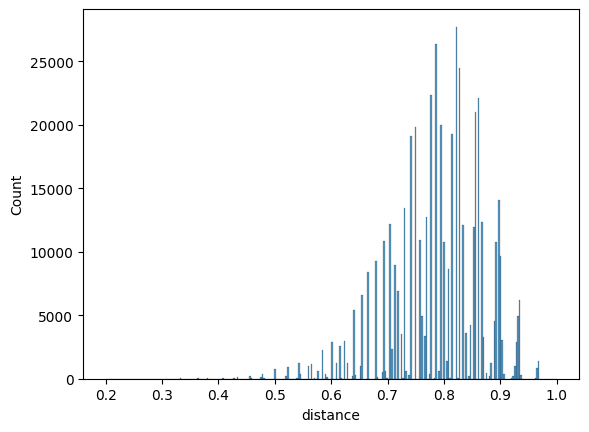

In [113]:
sns.histplot(result_df, x='distance')

In [114]:
result_df

,index_1,index_2,row_1,row_2,distance
0,1,0,88354,60553,0.833333
1,2,0,69413,60553,0.933333
2,2,1,69413,88354,0.827586
3,3,0,26656,60553,0.892857
4,3,1,26656,88354,0.862069
...,...,...,...,...,...
499495,999,994,59507,60224,0.793103
499496,999,995,59507,12460,0.800000
499497,999,996,59507,88222,0.678571
499498,999,997,59507,21620,0.642857


In [97]:
R = 0.55
df_R = result_df[result_df.distance < R]

G=nx.from_pandas_edgelist(df_R, 'row_1', 'row_2', edge_attr='distance')

In [98]:
nx.is_connected(G)

True

In [105]:
nx.diameter(G)

9

In [106]:
G_biggest_simplex = G.subgraph(sorted(nx.find_cliques(G), key=len, reverse=True)[0])

In [108]:
G_biggest_simplex.degree

DegreeView({18881: 10, 9474: 10, 38980: 10, 90020: 10, 37478: 10, 67724: 10, 44047: 10, 60178: 10, 2450: 10, 74292: 10, 19992: 10})

In [111]:
result_df

,row_1,row_2,distance
0,84191,17409,0.793103
1,19023,17409,0.827586
2,19023,84191,0.703704
3,49585,17409,0.703704
4,49585,84191,0.827586
...,...,...,...
499495,56300,61842,0.541667
499496,56300,82467,0.851852
499497,56300,73890,0.851852
499498,56300,21226,0.769231


In [115]:
result_df.pivot(index='index_1', columns='index_2', values='distance')

index_2,0,1,2,3,4,5,6,7,8,9,...,989,990,991,992,993,994,995,996,997,998
index_1,,,,,,,,,,,,,,,,,,,,,
1,0.833333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.933333,0.827586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.892857,0.862069,0.758621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.730769,0.692308,0.851852,0.814815,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.862069,0.777778,0.750000,0.785714,0.636364,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.785714,0.758621,0.640000,0.777778,0.769231,0.777778,0.769231,0.785714,0.777778,0.933333,...,0.785714,0.931034,0.851852,0.769231,0.692308,0.666667,NaN,NaN,NaN,NaN
996,0.862069,0.793103,0.833333,0.862069,0.857143,0.821429,0.857143,0.903226,0.680000,0.968750,...,0.740741,0.896552,0.708333,0.862069,0.866667,0.833333,0.750000,NaN,NaN,NaN
997,0.827586,0.758621,0.793103,0.740741,0.821429,0.862069,0.857143,0.906250,0.821429,0.967742,...,0.653846,0.857143,0.857143,0.896552,0.833333,0.758621,0.758621,0.714286,NaN,NaN


In [151]:
train_df = pd.get_dummies(df_o_fillna)

reducer = umap.UMAP(metric='rogerstanimoto', n_components=2, n_neighbors=100)

embedding_o = reducer.fit_transform(train_df)

# embedding_o = pd.DataFrame(embedding_o)

# embedding_o.columns = ['x','y']

# sns.scatterplot(embedding_o, x='x', y='y')



/home/fnnsll/.cache/pypoetry/virtualenvs/synthetic-ar5qwqp6-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/fnnsll/.cache/pypoetry/virtualenvs/synthetic-ar5qwqp6-py3.12/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for rogerstanimoto distance metric; inverse_transform will be unavailable
  warn(


In [181]:
plot_df = pd.DataFrame(embedding_o)

plot_df.columns = [f'col{i}' for i in range(plot_df.shape[1])]

final_plot_df = pd.DataFrame()

for i in range(plot_df.shape[1]):
    for j in range(plot_df.shape[1]):
        if i >= j:
            col1 = f'col{i}'
            col2 = f'col{j}'
            tmp_df = plot_df[[col1, col2]]
            tmp_df.columns = ['x','y']
            tmp_df['value_1'] = [i]*tmp_df.shape[0]
            tmp_df['value_2'] = [j]*tmp_df.shape[0]
            final_plot_df = pd.concat([final_plot_df, tmp_df], axis = 0)

/tmp/ipykernel_9281/669437828.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['value_1'] = [i]*tmp_df.shape[0]
/tmp/ipykernel_9281/669437828.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['value_2'] = [j]*tmp_df.shape[0]
/tmp/ipykernel_9281/669437828.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

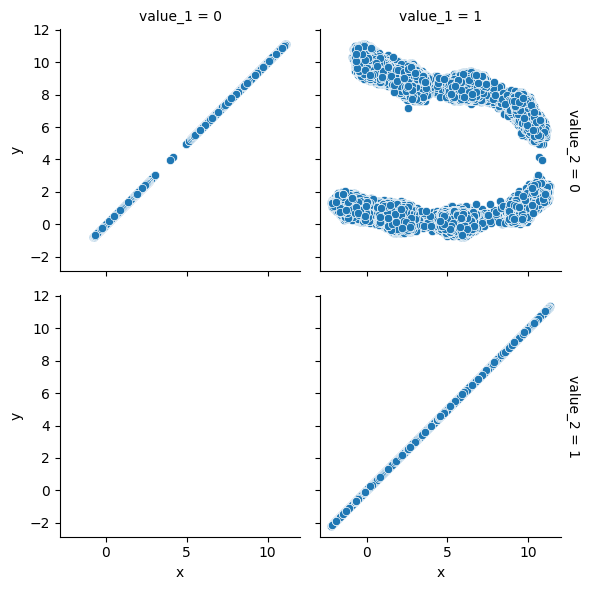

In [182]:
import matplotlib.pyplot as plt
#import hdbscan
import sklearn.cluster as cluster

kmeans_labels = cluster.KMeans(n_clusters=2).fit_predict(embedding_o)

g = sns.FacetGrid(final_plot_df.reset_index(), col='value_1', row='value_2', margin_titles=True)
g.map_dataframe(sns.scatterplot, x='x', y='y')
plt.show()

In [ ]:
pd.Series(kmeans_labels)

0    50008
1    49992
Name: count, dtype: int64

In [184]:
plot_df

,col0,col1,label
0,-0.204222,1.890435,1
1,6.683383,10.359508,1
2,0.707426,9.252043,1
3,8.958817,6.858938,0
4,0.765964,1.834444,1
...,...,...,...
99995,8.715944,6.879468,0
99996,5.809759,10.283940,1
99997,6.539016,9.752587,1
99998,-0.236475,2.188815,1


In [190]:
plot_df['label'] = pd.Series(kmeans_labels)
plot_df['label_visual'] = (plot_df['col0'] > 4.9).astype('int')

<Axes: xlabel='col0', ylabel='col1'>

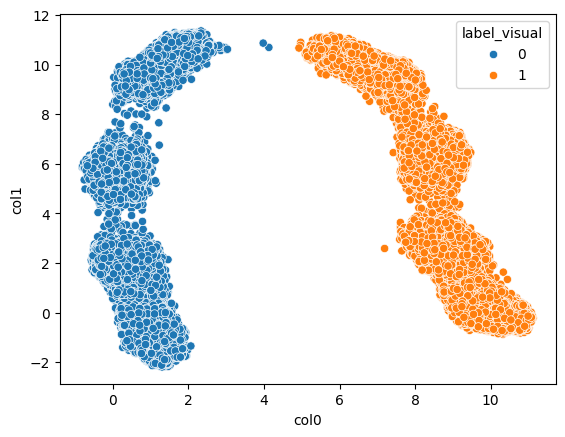

In [191]:
sns.scatterplot(plot_df, x='col0', y='col1', hue='label_visual' )

In [192]:
numeric_plot_df['label'] = plot_df['label']
numeric_plot_df['label_visual'] = plot_df['label_visual']

In [194]:
numeric_plot_df

,col0,col1,label,label_visual
0,14.097055,-6.466329,1,0
1,14.412957,-6.691614,1,1
2,13.312417,-5.823948,1,0
3,6.651218,-7.184950,0,1
4,16.141571,6.590018,1,0
...,...,...,...,...
99995,6.135317,-0.634520,0,1
99996,10.688671,-4.089170,1,1
99997,14.356757,-7.849612,1,1
99998,7.073303,-1.173874,1,0


<Axes: xlabel='col0', ylabel='col1'>

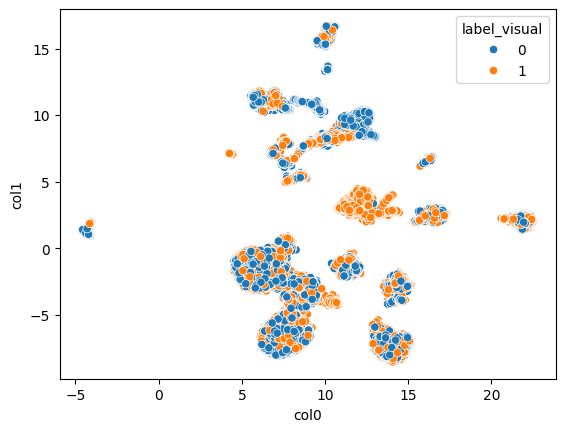

In [195]:
sns.scatterplot(numeric_plot_df, x='col0', y='col1', hue='label_visual' )